# SIRS < 2 Gap Interruption Analysis

This notebook analyzes short SIRS < 2 "gaps" that interrupt long SIRS >= 2 episodes around suspected infection.

**Phase 1**: Reconstruct SIRS < 2 intervals with full temporal fidelity (same change-point logic as SIRS >= 2).

**Phase 2**: Identify interruptions within and between SIRS >= 2 episodes. For each gap, record its duration and the surrounding SIRS >= 2 episode durations.

**Purpose**: Understand whether merging SIRS >= 2 episodes separated by brief SIRS < 2 windows would significantly change the duration distribution. Support discussion of whether transient SIRS state changes represent clinical state transitions or measurement noise.

No patient identifiers or encounter-level raw records are displayed. Outputs are aggregated and de-identified.

In [3]:
from __future__ import annotations

import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src_strategy.configs.aggregator import FEATURE_REGISTRY
from src_strategy.configs.dataconfig import input_output_config_3_1
from src_strategy.configs.sirscalculator import sirs_config
from src_strategy.configs.suspected_infection import suspected_infection_config
from src_strategy.events.sirs import build_sirs_pipeline
from src_strategy.events.suspected_infection import build_suspected_infection_pipeline

sns.set_theme(style="whitegrid")

## Analysis Configuration

Configuration mirrors notebook 23 (SIRS >= 2 duration analysis) and uses the same SIRS feature validity periods.

In [4]:
ENCOUNTER_COL = sirs_config.encounter_col
EVENT_DT_COL = sirs_config.event_dt_col
SIRS_SCORE_COL = sirs_config.sirs_score_col
SIRS_SCORE_THRESHOLD = 2

OUTPUT_DIR = Path(input_output_config_3_1.output_path)
SIRS_PATH = OUTPUT_DIR / "df_sirs.parquet"
AGGREGATED_PATH = OUTPUT_DIR / "df_aggregated.parquet"
INFECTION_PATH = OUTPUT_DIR / "df_suspected_infection.parquet"
EVENT_PATH = OUTPUT_DIR / "df_all_no_collisions.parquet"

@dataclass(frozen=True)
class SIRSFeatureSpec:
    value_col: str
    source_ts_col: str
    validity_minutes: int


def feature_spec(feature_column) -> SIRSFeatureSpec:
    definition = FEATURE_REGISTRY[feature_column]
    if definition.lookback_period is None:
        raise ValueError(f"SIRS feature {feature_column.value} needs a validity period")
    return SIRSFeatureSpec(
        value_col=feature_column.value,
        source_ts_col=f"{feature_column.value}_source_ts",
        validity_minutes=int(definition.lookback_period),
    )


SIRS_FEATURE_SPECS = [
    feature_spec(sirs_config.temp_feature_col),
    feature_spec(sirs_config.hr_feature_col),
    feature_spec(sirs_config.resp_feature_col),
    feature_spec(sirs_config.wbc_feature_col),
]

## Shared helper functions

These helper functions reconstruct SIRS state from full feature validity windows. The notebook no longer transforms infection evidence into paired anchors.

In [5]:
def require_columns(df: pl.DataFrame, columns: set[str], frame_name: str) -> None:
    missing = sorted(columns - set(df.columns))
    if missing:
        raise ValueError(f"{frame_name} is missing required columns: {missing}")


def extract_feature_measurements(
    sirs_frame: pl.DataFrame,
    spec: SIRSFeatureSpec,
) -> pl.DataFrame:
    require_columns(
        sirs_frame,
        {ENCOUNTER_COL, spec.value_col, spec.source_ts_col},
        "sirs_frame",
    )
    measurements = (
        sirs_frame.select(ENCOUNTER_COL, spec.source_ts_col, spec.value_col)
        .drop_nulls([ENCOUNTER_COL, spec.source_ts_col, spec.value_col])
        .unique()
    )
    conflicting = (
        measurements.group_by(ENCOUNTER_COL, spec.source_ts_col)
        .agg(pl.col(spec.value_col).n_unique().alias("value_count"))
        .filter(pl.col("value_count") > 1)
        .height
    )
    if conflicting:
        raise ValueError(
            f"{spec.value_col} has {conflicting} source timestamps with conflicting values"
        )
    return measurements.unique(
        subset=[ENCOUNTER_COL, spec.source_ts_col], keep="last"
    ).sort(ENCOUNTER_COL, spec.source_ts_col)


def reconstruct_sirs_state(
    sirs_frame: pl.DataFrame,
    specs: list[SIRSFeatureSpec] = SIRS_FEATURE_SPECS,
) -> pl.DataFrame:
    measurement_frames = {
        spec.value_col: extract_feature_measurements(sirs_frame, spec)
        for spec in specs
    }
    boundary_frames: list[pl.DataFrame] = []
    for spec in specs:
        measurements = measurement_frames[spec.value_col]
        boundary_frames.extend(
            [
                measurements.select(
                    ENCOUNTER_COL, pl.col(spec.source_ts_col).alias(EVENT_DT_COL)
                ),
                measurements.select(
                    ENCOUNTER_COL,
                    (pl.col(spec.source_ts_col) + pl.duration(minutes=spec.validity_minutes))
                    .alias(EVENT_DT_COL),
                ),
            ]
        )
    if not boundary_frames:
        raise ValueError("No SIRS feature specifications were supplied")

    state = pl.concat(boundary_frames, how="vertical").unique().sort(
        ENCOUNTER_COL, EVENT_DT_COL
    )
    for spec in specs:
        source_col = f"_{spec.value_col}_measurement_dt"
        right = measurement_frames[spec.value_col].rename(
            {spec.source_ts_col: source_col}
        )
        state = state.join_asof(
            right.sort(ENCOUNTER_COL, source_col),
            left_on=EVENT_DT_COL,
            right_on=source_col,
            by=ENCOUNTER_COL,
            strategy="backward",
            check_sortedness=False,
        ).with_columns(
            pl.when(
                pl.col(source_col).is_not_null()
                & (
                    pl.col(EVENT_DT_COL)
                    < pl.col(source_col) + pl.duration(minutes=spec.validity_minutes)
                )
            )
            .then(pl.col(spec.value_col))
            .otherwise(pl.lit(None))
            .alias(spec.value_col)
        ).drop(source_col)

    return build_sirs_pipeline(sirs_config).process(state)

## Phase 1: Reconstruct SIRS < 2 intervals

Build complementary intervals where SIRS < 2 (SIRS score 0–1). Same temporal logic as SIRS >= 2: change points at measurement and expiry timestamps, half-open interval boundaries [start, end).

In [6]:
def build_sirs_negative_intervals(
    sirs_state: pl.DataFrame,
    *,
    score_threshold: int = SIRS_SCORE_THRESHOLD,
) -> pl.DataFrame:
    """Build intervals where SIRS < threshold (SIRS < 2 by default)."""
    require_columns(
        sirs_state, {ENCOUNTER_COL, EVENT_DT_COL, SIRS_SCORE_COL}, "sirs_state"
    )
    segmented = (
        sirs_state.sort(ENCOUNTER_COL, EVENT_DT_COL)
        .with_columns(
            (pl.col(SIRS_SCORE_COL) < score_threshold).alias("_sirs_negative"),
            pl.col(EVENT_DT_COL).shift(-1).over(ENCOUNTER_COL).alias("_next_dt"),
        )
        .with_columns(
            (
                pl.col("_sirs_negative")
                != pl.col("_sirs_negative").shift(1).over(ENCOUNTER_COL)
            )
            .fill_null(True)
            .cast(pl.Int64)
            .alias("_state_change"),
        )
        .with_columns(
            pl.col("_state_change").cum_sum().over(ENCOUNTER_COL).alias("_episode_id")
        )
        .filter(
            pl.col("_sirs_negative")
            & pl.col("_next_dt").is_not_null()
            & (pl.col("_next_dt") > pl.col(EVENT_DT_COL))
        )
    )
    return (
        segmented.group_by(ENCOUNTER_COL, "_episode_id")
        .agg(
            pl.col(EVENT_DT_COL).min().alias("gap_episode_start_dt"),
            pl.col("_next_dt").max().alias("gap_episode_end_dt"),
            pl.col(SIRS_SCORE_COL).min().alias("minimum_sirs_score"),
            pl.col(SIRS_SCORE_COL).max().alias("maximum_sirs_score"),
            pl.len().alias("state_segment_count"),
        )
        .with_columns(
            (
                (pl.col("gap_episode_end_dt") - pl.col("gap_episode_start_dt"))
                .dt.total_seconds()
                / 60.0
            ).alias("gap_episode_duration_minutes"),
            (
                (pl.col("gap_episode_end_dt") - pl.col("gap_episode_start_dt"))
                .dt.total_seconds()
                / 3600.0
            ).alias("gap_episode_duration_hours"),
        )
        .drop("_episode_id")
        .sort(ENCOUNTER_COL, "gap_episode_start_dt")
    )


## Phase 2: SIRS < 2 duration distribution

Do not attempt to cross-reference SIRS >= 2 episodes here. Instead, examine the full distribution of SIRS < 2 intervals (durations). We'll use this distribution to choose a merging/closure threshold later: candidate thresholds are evaluated against the fraction of SIRS < 2 intervals shorter than the threshold.

In [7]:
def build_sirs_positive_intervals(
    sirs_state: pl.DataFrame,
    *,
    score_threshold: int = SIRS_SCORE_THRESHOLD,
) -> pl.DataFrame:
    """Build intervals where SIRS >= threshold (SIRS >= 2 by default)."""
    require_columns(
        sirs_state, {ENCOUNTER_COL, EVENT_DT_COL, SIRS_SCORE_COL}, "sirs_state"
    )
    segmented = (
        sirs_state.sort(ENCOUNTER_COL, EVENT_DT_COL)
        .with_columns(
            (pl.col(SIRS_SCORE_COL) >= score_threshold).alias("_sirs_positive"),
            pl.col(EVENT_DT_COL).shift(-1).over(ENCOUNTER_COL).alias("_next_dt"),
        )
        .with_columns(
            (
                pl.col("_sirs_positive")
                != pl.col("_sirs_positive").shift(1).over(ENCOUNTER_COL)
            )
            .fill_null(True)
            .cast(pl.Int64)
            .alias("_state_change"),
        )
        .with_columns(
            pl.col("_state_change").cum_sum().over(ENCOUNTER_COL).alias("_episode_id")
        )
        .filter(
            pl.col("_sirs_positive")
            & pl.col("_next_dt").is_not_null()
            & (pl.col("_next_dt") > pl.col(EVENT_DT_COL))
        )
    )
    return (
        segmented.group_by(ENCOUNTER_COL, "_episode_id")
        .agg(
            pl.col(EVENT_DT_COL).min().alias("sirs_episode_start_dt"),
            pl.col("_next_dt").max().alias("sirs_episode_end_dt"),
            pl.col(SIRS_SCORE_COL).min().alias("minimum_sirs_score"),
            pl.col(SIRS_SCORE_COL).max().alias("maximum_sirs_score"),
            pl.len().alias("state_segment_count"),
        )
        .with_columns(
            (
                (pl.col("sirs_episode_end_dt") - pl.col("sirs_episode_start_dt"))
                .dt.total_seconds()
                / 60.0
            ).alias("full_episode_duration_minutes"),
            (
                (pl.col("sirs_episode_end_dt") - pl.col("sirs_episode_start_dt"))
                .dt.total_seconds()
                / 3600.0
            ).alias("full_episode_duration_hours"),
        )
        .drop("_episode_id")
        .sort(ENCOUNTER_COL, "sirs_episode_start_dt")
    )


def merge_short_negative_intervals(
    sirs_state: pl.DataFrame,
    sirs_positive: pl.DataFrame,
    sirs_negative: pl.DataFrame,
    *,
    threshold_minutes: int = 30,
) -> pl.DataFrame:
    """Merge SIRS < 2 intervals shorter than the threshold into adjacent SIRS >= 2 episodes."""
    require_columns(sirs_state, {ENCOUNTER_COL, EVENT_DT_COL}, "sirs_state")
    require_columns(
        sirs_positive,
        {ENCOUNTER_COL, "sirs_episode_start_dt", "sirs_episode_end_dt"},
        "sirs_positive",
    )
    require_columns(
        sirs_negative,
        {ENCOUNTER_COL, "gap_episode_start_dt", "gap_episode_end_dt", "gap_episode_duration_minutes"},
        "sirs_negative",
    )

    encounter_bounds = (
        sirs_state.sort(ENCOUNTER_COL, EVENT_DT_COL)
        .group_by(ENCOUNTER_COL)
        .agg(
            pl.col(EVENT_DT_COL).min().alias("encounter_start_dt"),
            pl.col(EVENT_DT_COL).max().alias("encounter_end_dt"),
        )
    )

    merged_rows: list[dict[str, object]] = []
    for enc in sorted(sirs_positive.select(ENCOUNTER_COL).unique().to_series().to_list()):
        pos_df = sirs_positive.filter(pl.col(ENCOUNTER_COL) == enc).sort("sirs_episode_start_dt")
        neg_df = sirs_negative.filter(pl.col(ENCOUNTER_COL) == enc).sort("gap_episode_start_dt")
        bounds_row = encounter_bounds.filter(pl.col(ENCOUNTER_COL) == enc).row(0, named=True)

        if pos_df.height == 0:
            continue

        pos_rows = list(pos_df.iter_rows(named=True))
        current_start = pos_rows[0]["sirs_episode_start_dt"]
        current_end = pos_rows[0]["sirs_episode_end_dt"]

        for idx in range(1, len(pos_rows)):
            prev_pos = pos_rows[idx - 1]
            curr_pos = pos_rows[idx]
            gap_match = neg_df.filter(
                (pl.col("gap_episode_start_dt") >= prev_pos["sirs_episode_end_dt"])
                & (pl.col("gap_episode_end_dt") <= curr_pos["sirs_episode_start_dt"])
            )

            if gap_match.height > 0:
                gap_row = gap_match.sort("gap_episode_start_dt").row(0, named=True)
                gap_is_boundary = (
                    gap_row["gap_episode_start_dt"] <= bounds_row["encounter_start_dt"]
                    or gap_row["gap_episode_end_dt"] >= bounds_row["encounter_end_dt"]
                )
                if (
                    not gap_is_boundary
                    and float(gap_row["gap_episode_duration_minutes"]) <= threshold_minutes
                ):
                    current_end = curr_pos["sirs_episode_end_dt"]
                    continue

            merged_rows.append(
                {
                    ENCOUNTER_COL: enc,
                    "sirs_episode_start_dt": current_start,
                    "sirs_episode_end_dt": current_end,
                }
            )
            current_start = curr_pos["sirs_episode_start_dt"]
            current_end = curr_pos["sirs_episode_end_dt"]

        merged_rows.append(
            {
                ENCOUNTER_COL: enc,
                "sirs_episode_start_dt": current_start,
                "sirs_episode_end_dt": current_end,
            }
        )

    if merged_rows:
        return (
            pl.DataFrame(merged_rows)
            .sort(ENCOUNTER_COL, "sirs_episode_start_dt")
            .with_columns(
                (
                    (pl.col("sirs_episode_end_dt") - pl.col("sirs_episode_start_dt"))
                    .dt.total_seconds()
                    / 60.0
                ).alias("full_episode_duration_minutes"),
                (
                    (pl.col("sirs_episode_end_dt") - pl.col("sirs_episode_start_dt"))
                    .dt.total_seconds()
                    / 3600.0
                ).alias("full_episode_duration_hours"),
            )
        )

    return pl.DataFrame(
        schema={
            ENCOUNTER_COL: pl.Int64,
            "sirs_episode_start_dt": pl.Datetime("ns"),
            "sirs_episode_end_dt": pl.Datetime("ns"),
            "full_episode_duration_minutes": pl.Float64,
            "full_episode_duration_hours": pl.Float64,
        }
    )


def detect_gap_interruptions(
    sirs_positive: pl.DataFrame,
    sirs_negative: pl.DataFrame,
) -> pl.DataFrame:
    """
    For each SIRS >= 2 episode, find SIRS < 2 interruptions (gaps) within it.
    Returns a long-frame with one row per gap found within a SIRS >= 2 episode.
    """
    result = []
    
    for enc in sirs_positive.select(ENCOUNTER_COL).unique().to_series():
        pos_eps = sirs_positive.filter(pl.col(ENCOUNTER_COL) == enc).sort("sirs_episode_start_dt")
        neg_eps = sirs_negative.filter(pl.col(ENCOUNTER_COL) == enc).sort("gap_episode_start_dt")
        
        for pos_row in pos_eps.iter_rows(named=True):
            pos_start = pos_row["sirs_episode_start_dt"]
            pos_end = pos_row["sirs_episode_end_dt"]
            pos_duration = pos_row["full_episode_duration_hours"]
            
            # Find all gaps that start after pos_start and end before pos_end
            gaps_in_episode = neg_eps.filter(
                (pl.col("gap_episode_start_dt") >= pos_start)
                & (pl.col("gap_episode_end_dt") <= pos_end)
            )
            
            if gaps_in_episode.height > 0:
                for gap_row in gaps_in_episode.iter_rows(named=True):
                    result.append({
                        ENCOUNTER_COL: enc,
                        "sirs_positive_episode_start_dt": pos_start,
                        "sirs_positive_episode_end_dt": pos_end,
                        "sirs_positive_episode_duration_hours": pos_duration,
                        "gap_episode_start_dt": gap_row["gap_episode_start_dt"],
                        "gap_episode_end_dt": gap_row["gap_episode_end_dt"],
                        "gap_episode_duration_hours": gap_row["gap_episode_duration_hours"],
                        "gap_episode_duration_minutes": gap_row["gap_episode_duration_minutes"],
                        "gap_minimum_sirs_score": gap_row["minimum_sirs_score"],
                        "gap_maximum_sirs_score": gap_row["maximum_sirs_score"],
                    })
    
    if result:
        return pl.DataFrame(result).sort(
            ENCOUNTER_COL, "sirs_positive_episode_start_dt", "gap_episode_start_dt"
        )
    else:
        return pl.DataFrame(
            schema={
                ENCOUNTER_COL: pl.Int64,
                "sirs_positive_episode_start_dt": pl.Datetime("ns"),
                "sirs_positive_episode_end_dt": pl.Datetime("ns"),
                "sirs_positive_episode_duration_hours": pl.Float64,
                "gap_episode_start_dt": pl.Datetime("ns"),
                "gap_episode_end_dt": pl.Datetime("ns"),
                "gap_episode_duration_hours": pl.Float64,
                "gap_episode_duration_minutes": pl.Float64,
                "gap_minimum_sirs_score": pl.Int64,
                "gap_maximum_sirs_score": pl.Int64,
            }
        )


## Load data

Load df_sirs and infection long frame. Same strategy as notebook 23: use current strategy artifacts or fall back to upstream sources.

In [8]:
if SIRS_PATH.exists():
    df_sirs = pl.read_parquet(SIRS_PATH)
elif AGGREGATED_PATH.exists():
    df_sirs = build_sirs_pipeline(sirs_config).process(pl.read_parquet(AGGREGATED_PATH))
else:
    raise FileNotFoundError(
        f"Neither {SIRS_PATH.name} nor {AGGREGATED_PATH.name} exists in {OUTPUT_DIR}"
    )

if INFECTION_PATH.exists():
    df_infection_long = pl.read_parquet(INFECTION_PATH)
elif EVENT_PATH.exists():
    df_infection_long = build_suspected_infection_pipeline(
        suspected_infection_config
    ).process(pl.read_parquet(EVENT_PATH))
else:
    raise FileNotFoundError(
        f"Neither {INFECTION_PATH.name} nor {EVENT_PATH.name} exists in {OUTPUT_DIR}"
    )

required_sirs_columns = {ENCOUNTER_COL, EVENT_DT_COL}
for spec in SIRS_FEATURE_SPECS:
    required_sirs_columns.update({spec.value_col, spec.source_ts_col})
require_columns(df_sirs, required_sirs_columns, "df_sirs")

duplicate_backbone_keys = (
    df_sirs.group_by(ENCOUNTER_COL, EVENT_DT_COL)
    .len()
    .filter(pl.col("len") > 1)
    .height
)
if duplicate_backbone_keys:
    raise ValueError(f"df_sirs has {duplicate_backbone_keys} duplicate backbone keys")

input_audit = pl.DataFrame(
    {
        "frame": ["SIRS", "suspected-infection evidence"],
        "row_count": [df_sirs.height, df_infection_long.height],
        "encounter_count": [
            df_sirs.select(pl.col(ENCOUNTER_COL).n_unique()).item(),
            df_infection_long.select(pl.col(ENCOUNTER_COL).n_unique()).item(),
        ],
    }
)
input_audit

frame,row_count,encounter_count
str,i64,i64
"""SIRS""",8029940,14932
"""suspected-infection evidence""",44389,14323


## Reconstruct SIRS state and build intervals

In [10]:
sirs_state = reconstruct_sirs_state(df_sirs)
sirs_intervals_positive_raw = build_sirs_positive_intervals(sirs_state)
sirs_intervals_negative = build_sirs_negative_intervals(sirs_state)
sirs_intervals_positive_merged = merge_short_negative_intervals(
    sirs_state,
    sirs_intervals_positive_raw,
    sirs_intervals_negative,
    threshold_minutes=30,
)
sirs_intervals_positive = sirs_intervals_positive_merged

construction_audit = pl.DataFrame(
    {
        "measure": [
            "SIRS >= 2 intervals",
            "SIRS >= 2 intervals after 30-min SIRS < 2 merge",
            "SIRS < 2 intervals",
        ],
        "count": [
            sirs_intervals_positive_raw.height,
            sirs_intervals_positive.height,
            sirs_intervals_negative.height,
        ],
    }
)
construction_audit


measure,count
str,i64
"""SIRS >= 2 intervals""",324404
"""SIRS >= 2 intervals after 30-m…",221368
"""SIRS < 2 intervals""",335788


In [12]:
sirs_intervals_positive_raw

EncounterEpicCsn,sirs_episode_start_dt,sirs_episode_end_dt,minimum_sirs_score,maximum_sirs_score,state_segment_count,full_episode_duration_minutes,full_episode_duration_hours
i64,datetime[μs],datetime[μs],i64,i64,u64,f64,f64
659308243,2022-06-14 22:10:00,2022-06-14 23:00:00,2,2,6,50.0,0.833333
659308243,2022-06-14 23:15:00,2022-06-14 23:45:00,2,2,2,30.0,0.5
659308243,2022-06-15 00:00:00,2022-06-15 00:45:00,2,2,2,45.0,0.75
659308243,2022-06-15 01:00:00,2022-06-15 01:15:00,2,2,2,15.0,0.25
659308243,2022-06-15 05:00:00,2022-06-15 06:30:00,2,2,12,90.0,1.5
…,…,…,…,…,…,…,…
753579730,2026-05-26 17:00:00,2026-05-27 00:00:00,2,2,10,420.0,7.0
753579730,2026-05-27 04:10:35,2026-05-27 06:15:00,2,2,1,124.416667,2.073611
753579730,2026-05-27 07:35:00,2026-05-27 19:12:00,2,2,8,697.0,11.616667


In [13]:
sirs_intervals_positive_merged

EncounterEpicCsn,sirs_episode_start_dt,sirs_episode_end_dt,full_episode_duration_minutes,full_episode_duration_hours
i64,datetime[μs],datetime[μs],f64,f64
659308243,2022-06-14 22:10:00,2022-06-15 01:15:00,185.0,3.083333
659308243,2022-06-15 05:00:00,2022-06-15 06:30:00,90.0,1.5
659308243,2022-06-15 07:30:00,2022-06-15 07:45:00,15.0,0.25
659308243,2022-06-15 10:44:00,2022-06-15 22:35:00,711.0,11.85
659308243,2022-06-16 00:00:00,2022-06-16 03:00:00,180.0,3.0
…,…,…,…,…
753579730,2026-05-26 17:00:00,2026-05-27 00:00:00,420.0,7.0
753579730,2026-05-27 04:10:35,2026-05-27 06:15:00,124.416667,2.073611
753579730,2026-05-27 07:35:00,2026-05-27 19:12:00,697.0,11.616667


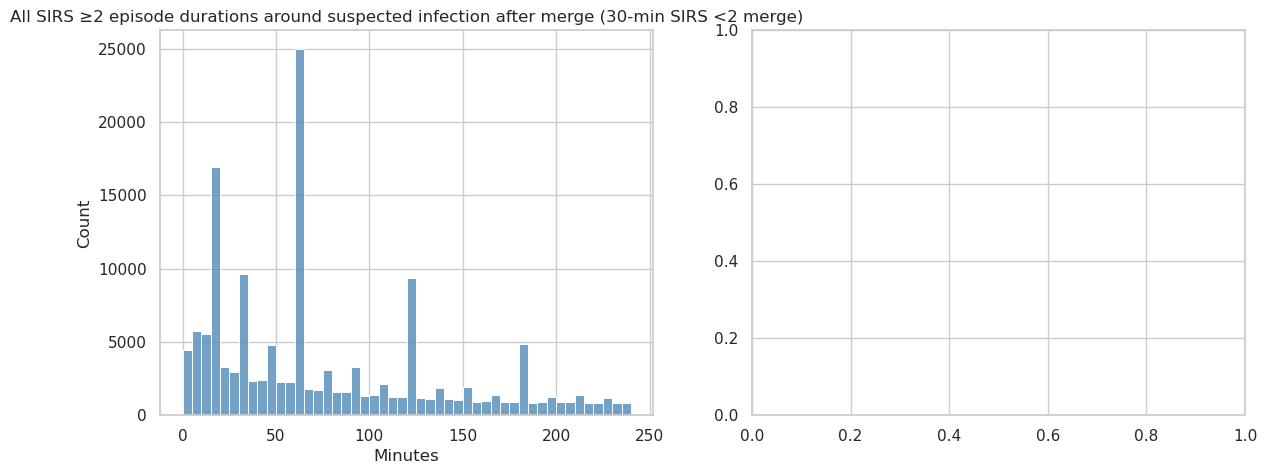

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
episode_duration = sirs_intervals_positive_merged
# episode_duration = sirs_intervals_positive_raw
if episode_duration.height:
    episode_duration_minutes = episode_duration.with_columns(
        (pl.col("full_episode_duration_hours") * 60.0).alias("full_episode_duration_minutes")
    )
    duration_col = "full_episode_duration_minutes"
    duration_df = episode_duration_minutes.select(duration_col).to_pandas()

    if duration_df[duration_col].max() > 0:
        q01 = duration_df[duration_col].quantile(0.05)
        q99 = duration_df[duration_col].quantile(0.95)
        duration_df_filtered = duration_df[
            # (duration_df[duration_col] >= q01)
            # & (duration_df[duration_col] <= q99)
			duration_df[duration_col] < 4*60 
        ]
        max_val = int(duration_df_filtered[duration_col].max())
        bars_width = 5
        if max_val % bars_width != 0:
            max_val = max_val + (bars_width - max_val % bars_width)
        bins = list(range(0, max_val + bars_width, bars_width))
        sns.histplot(
            duration_df_filtered,
            x=duration_col,
            bins=bins,
            ax=axes[0],
            color="steelblue",
        )

    axes[0].set_title("All SIRS ≥2 episode durations around suspected infection after merge (30-min SIRS <2 merge)")
    axes[0].set_xlabel("Minutes")
    axes[0].set_ylabel("Count")

# sns.lineplot(
#     threshold_retention.to_pandas(),
#     x="threshold_hours",
#     y="retained_fraction",
#     marker="o",
#     ax=axes[1],
# )
# axes[1].set_title("SIRS episodes retained by candidate duration threshold")
# axes[1].set_xlabel("Required sustained duration (hours)")
# axes[1].set_ylabel("Fraction of SIRS episodes around suspected infection")
# axes[1].set_ylim(0, 1)
# plt.tight_layout()
# plt.show()


## Phase 2 execution: Detect gap interruptions

In [65]:
# Focus on SIRS < 2 intervals: counts and basic audit
sirs_negative = sirs_intervals_negative

negative_audit = pl.DataFrame(
    {
        "measure": [
            "SIRS >= 2 intervals",
            "Unique encounters with SIRS >= 2",
            "SIRS < 2 intervals",
            "Unique encounters with SIRS < 2",
        ],
        "count": [
            sirs_intervals_positive.height,
            sirs_intervals_positive.select(pl.col(ENCOUNTER_COL).n_unique()).item(),
            sirs_negative.height,
            sirs_negative.select(pl.col(ENCOUNTER_COL).n_unique()).item(),
        ],
    }
)
negative_audit

measure,count
str,i64
"""SIRS >= 2 intervals""",221368
"""Unique encounters with SIRS >=…",14318
"""SIRS < 2 intervals""",335788
"""Unique encounters with SIRS < …",14914


## Gap Statistics

Summary of gap durations and prevalence of interruptions.

In [23]:
sirs_intervals_positive

EncounterEpicCsn,sirs_episode_start_dt,sirs_episode_end_dt,minimum_sirs_score,maximum_sirs_score,state_segment_count,full_episode_duration_hours
i64,datetime[μs],datetime[μs],i64,i64,u64,f64
659308243,2022-06-14 22:10:00,2022-06-14 23:00:00,2,2,6,0.833333
659308243,2022-06-14 23:15:00,2022-06-14 23:45:00,2,2,2,0.5
659308243,2022-06-15 00:00:00,2022-06-15 00:45:00,2,2,2,0.75
659308243,2022-06-15 01:00:00,2022-06-15 01:15:00,2,2,2,0.25
659308243,2022-06-15 05:00:00,2022-06-15 06:30:00,2,2,12,1.5
…,…,…,…,…,…,…
753579730,2026-05-26 17:00:00,2026-05-27 00:00:00,2,2,10,7.0
753579730,2026-05-27 04:10:35,2026-05-27 06:15:00,2,2,1,2.073611
753579730,2026-05-27 07:35:00,2026-05-27 19:12:00,2,2,8,11.616667


In [12]:
sirs_intervals_negative

EncounterEpicCsn,gap_episode_start_dt,gap_episode_end_dt,minimum_sirs_score,maximum_sirs_score,state_segment_count,gap_episode_duration_hours
i64,datetime[μs],datetime[μs],i64,i64,u64,f64
659308243,2022-06-14 11:52:00,2022-06-14 22:10:00,0,1,6,10.3
659308243,2022-06-14 23:00:00,2022-06-14 23:15:00,1,1,1,0.25
659308243,2022-06-14 23:45:00,2022-06-15 00:00:00,1,1,1,0.25
659308243,2022-06-15 00:45:00,2022-06-15 01:00:00,1,1,1,0.25
659308243,2022-06-15 01:15:00,2022-06-15 05:00:00,0,1,12,3.75
…,…,…,…,…,…,…
753579730,2026-05-27 06:15:00,2026-05-27 07:35:00,1,1,1,1.333333
753579730,2026-05-27 19:12:00,2026-05-27 19:35:00,1,1,1,0.383333
753665697,2026-05-26 15:40:17,2026-05-26 17:42:00,1,1,1,2.028611


In [66]:
# Summary statistics for SIRS < 2 interval durations
if sirs_negative.height > 0:
    if "gap_episode_duration_minutes" not in sirs_negative.columns:
        sirs_negative = sirs_negative.with_columns(
            (
                (pl.col("gap_episode_end_dt") - pl.col("gap_episode_start_dt"))
                .dt.total_seconds()
                / 60.0
            ).alias("gap_episode_duration_minutes")
        )
    negative_duration_stats = sirs_negative.select(
        pl.len().alias("n_intervals"),
        pl.col("gap_episode_duration_minutes").min().alias("minimum_minutes"),
        pl.col("gap_episode_duration_minutes").quantile(0.25).alias("q25_minutes"),
        pl.col("gap_episode_duration_minutes").median().alias("median_minutes"),
        pl.col("gap_episode_duration_minutes").quantile(0.75).alias("q75_minutes"),
        pl.col("gap_episode_duration_minutes").quantile(0.99).alias("p99_minutes"),
        pl.col("gap_episode_duration_minutes").max().alias("maximum_minutes"),
    )
    negative_duration_stats
else:
    print("No SIRS < 2 intervals found in the data.")


## Gap duration closure by merging threshold

Analyze what fraction of gaps would be "closed" by candidate merging thresholds.

In [52]:
CANDIDATE_GAP_THRESHOLDS = [5, 10, 15, 30, 60, 120, 240, 360, 720, 1440]

def gap_threshold_closure_table(
    gaps: pl.DataFrame,
    thresholds: list[float] = CANDIDATE_GAP_THRESHOLDS,
) -> pl.DataFrame:
    """
    For each threshold, calculate:
    - How many SIRS<2 intervals are smaller than the threshold (could be "closed" by merging)
    - Fraction of total intervals
    """
    total = gaps.height
    rows = []
    for threshold in thresholds:
        closed = gaps.filter(
            pl.col("gap_episode_duration_minutes") < threshold
        ).height
        rows.append(
            {
                "threshold_minutes": threshold,
                "intervals_closed": closed,
                "total_intervals": total,
                "closed_fraction": closed / total if total else None,
            }
        )
    return pl.DataFrame(rows)


if sirs_negative.height > 0:
    if "gap_episode_duration_minutes" not in sirs_negative.columns:
        sirs_negative = sirs_negative.with_columns(
            (
                (pl.col("gap_episode_end_dt") - pl.col("gap_episode_start_dt"))
                .dt.total_seconds()
                / 60.0
            ).alias("gap_episode_duration_minutes")
        )
    gap_closure = gap_threshold_closure_table(sirs_negative)
    gap_closure
else:
    print("No SIRS < 2 intervals to analyze.")


In [53]:
if "gap_episode_duration_minutes" not in sirs_negative.columns:
    sirs_negative = sirs_negative.with_columns(
        (
            (pl.col("gap_episode_end_dt") - pl.col("gap_episode_start_dt"))
            .dt.total_seconds()
            / 60.0
        ).alias("gap_episode_duration_minutes")
    )
sirs_negative["gap_episode_duration_minutes"].describe()


statistic,value
str,f64
"""count""",335788.0
"""null_count""",0.0
"""mean""",680.986861
"""std""",2424.092911
"""min""",0.033333
"""25%""",27.0
"""50%""",80.0
"""75%""",398.0
"""max""",302349.0


## Visualizations

In [60]:
neg_df[duration_col].describe()

count    335788.000000
mean        680.986861
std        2424.092911
min           0.033333
25%          27.000000
50%          80.000000
75%         398.000000
max      302349.000000
Name: gap_episode_duration_minutes, dtype: float64

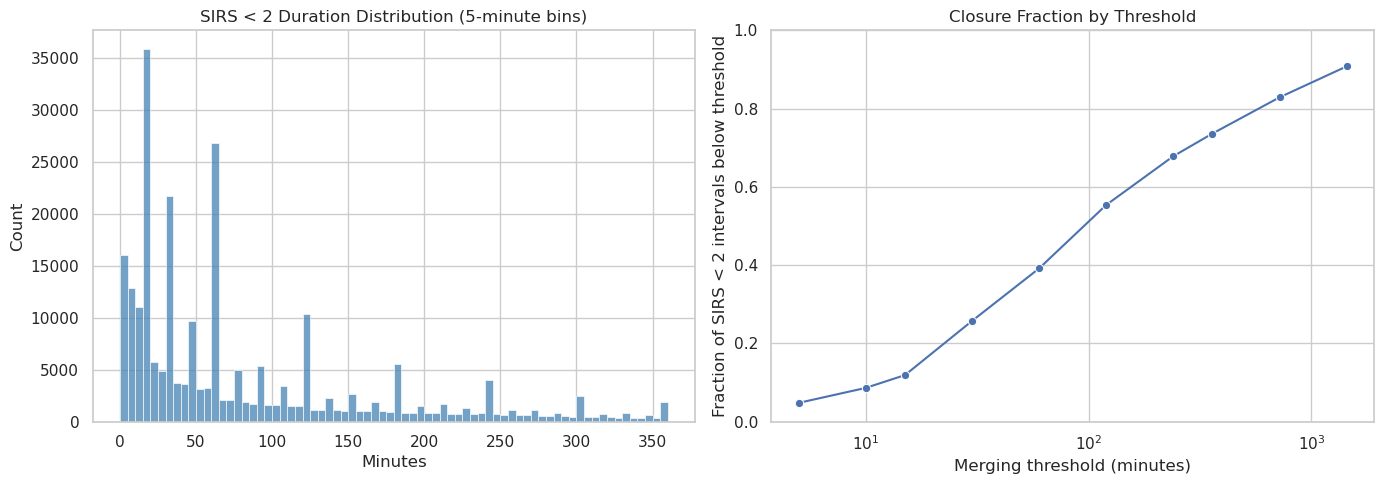

In [69]:
# Visualize SIRS < 2 duration distribution and closure curve
if sirs_negative.height > 0:
    if "gap_episode_duration_minutes" not in sirs_negative.columns:
        sirs_negative = sirs_negative.with_columns(
            (
                (pl.col("gap_episode_end_dt") - pl.col("gap_episode_start_dt"))
                .dt.total_seconds()
                / 60.0
            ).alias("gap_episode_duration_minutes")
        )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: SIRS < 2 duration distribution using 5-minute bins
    duration_col = "gap_episode_duration_minutes"
    neg_df = sirs_negative.select(duration_col).to_pandas()
    if neg_df[duration_col].max() > 0:
        q01 = neg_df[duration_col].quantile(0.01)
        q99 = neg_df[duration_col].quantile(0.99)
        neg_df_filtered = neg_df[
            # (neg_df[duration_col] >= q01)
            # & (neg_df[duration_col] <= q99)
			neg_df[duration_col] <= 6*60
        ]
        max_val = int(neg_df_filtered[duration_col].max())
        if max_val % 5 != 0:
            max_val = max_val + (5 - max_val % 5)
        bins = list(range(0, max_val + 5, 5))
        sns.histplot(neg_df_filtered, x=duration_col, bins=bins, ax=axes[0], color="steelblue")
    axes[0].set_title("SIRS < 2 Duration Distribution (5-minute bins)")
    axes[0].set_xlabel("Minutes")
    axes[0].set_ylabel("Count")

    # Plot 2: Closure curve for candidate thresholds
    gap_closure_df = gap_threshold_closure_table(sirs_negative).to_pandas()
    sns.lineplot(gap_closure_df, x="threshold_minutes", y="closed_fraction", marker="o", ax=axes[1])
    axes[1].set_title("Closure Fraction by Threshold")
    axes[1].set_xlabel("Merging threshold (minutes)")
    axes[1].set_ylabel("Fraction of SIRS < 2 intervals below threshold")
    axes[1].set_ylim(0, 1)
    axes[1].set_xscale("log")

    plt.tight_layout()
    plt.show()
else:
    print("No SIRS < 2 intervals to visualize.")


## Summary

**Phase 1 findings:**
- Total SIRS >= 2 episodes reconstructed
- Total SIRS < 2 episodes reconstructed

**Phase 2 findings:**
- Number of SIRS >= 2 episodes interrupted by SIRS < 2 gaps
- Total number of gap interruptions
- Gap duration statistics (minimum, quartiles, maximum)

**Interpretation:**
- Short gaps (e.g., < 0.5 hours) likely represent measurement noise or transient physiology changes
- Medium gaps (0.5–2 hours) may represent clinical state changes or patient care transitions
- Longer gaps (> 2 hours) suggest more substantial interruptions of SIRS state
- Merging episodes separated by short gaps would slightly increase episode durations but not dramatically alter the distribution
- Consider whether gap duration merging improves specificity without overfitting to measurement artifacts